Parte 1: QLearning Lineal en MountainCar

T1: Setup


In [36]:
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0")
print("Estado (continuo):", env.observation_space)  # Box(2,) — [pos, vel]
print("Acciones:", env.action_space)  # Discrete(3)
print("Limites pos:", env.observation_space.low[0], "a", env.observation_space.high[0])
print("Limites vel:", env.observation_space.low[1], "a", env.observation_space.high[1])


# Normalizar estado al rango [-1, 1] para estabilidad numerica
def normalize_state(obs):
    pos_range = env.observation_space.high[0] - env.observation_space.low[0]  # 1.8
    vel_range = env.observation_space.high[1] - env.observation_space.low[1]  # 0.14
    pos_norm = 2 * (obs[0] - env.observation_space.low[0]) / pos_range - 1
    vel_norm = 2 * (obs[1] - env.observation_space.low[1]) / vel_range - 1
    pos_norm = np.clip(pos_norm, -1.0, 1.0)
    vel_norm = np.clip(vel_norm, -1.0, 1.0)
    return np.array([pos_norm, vel_norm])


normalize_state(np.array([-0.5, -0.03]))  # ejemplo de normalizacion

Estado (continuo): Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Acciones: Discrete(3)
Limites pos: -1.2 a 0.6
Limites vel: -0.07 a 0.07


array([-0.2222222 , -0.42857143])

In [51]:
nA = env.action_space.n  # 3 acciones


# Conjunto A: basico (k = 3 variables x 3 acciones = 9)
def features_A(obs, action):
    s = normalize_state(obs)
    psi = np.array([s[0], s[1], 1.0])
    phi = np.zeros(len(psi) * nA)
    phi[action * len(psi) : (action + 1) * len(psi)] = psi
    return phi


# Conjunto B: polinomial (k = 9 terminos x 3 acciones = 27)
def features_B(obs, action):
    s = normalize_state(obs)
    x, v = s[0], s[1]
    psi = np.array([x, v, 1.0, x**2, v**2, x * v, x**3, v**3, x * (v**2)])
    phi = np.zeros(len(psi) * nA)
    phi[action * len(psi) : (action + 1) * len(psi)] = psi
    return phi


# Conjunto C: RBF (16 centros + 1 bias) x 3 acciones = 51
centers_x = np.linspace(-1, 1, 4)
centers_v = np.linspace(-1, 1, 4)
sigma = 1.5  # ancho del kernel


def features_RBF(obs, action):
    s = normalize_state(obs)
    psi = []
    for cx in centers_x:
        for cv in centers_v:
            dist2 = (s[0] - cx) ** 2 + (s[1] - cv) ** 2
            psi.append(np.exp(-dist2 / (2 * sigma**2)))
    psi.append(1.0)  # bias
    psi = np.array(psi)
    phi = np.zeros(len(psi) * nA)
    phi[action * len(psi) : (action + 1) * len(psi)] = psi
    return phi


print("k_A:", features_A(env.reset()[0], 1).shape[0])  # 9
print("k_B:", features_B(env.reset()[0], 0).shape[0])  # 27
print("k_C:", features_RBF(env.reset()[0], 0).shape[0])  # 51

k_A: 9
k_B: 27
k_C: 51


T2: Qlearning Lineal


In [35]:
def q_linear(
    env,
    feature_fn,
    k,
    n_episodes=2000,
    alpha=0.03,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
):
    """Q-Learning con VFA lineal y particionamiento por accion."""
    theta = np.zeros(k)  # parametros - inicializar a cero
    rewards = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        obs, _ = env.reset()
        total_r = 0

        while True:
            # ε-greedy: explorar o explotar
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                # argmax_a θ^T φ(s,a)
                Qs = [
                    np.dot(theta, feature_fn(obs, a)) for a in range(env.action_space.n)
                ]
                action = int(np.argmax(Qs))

            obs_next, r, done, truncated, _ = env.step(action)
            total_r += r

            # TD Error con Q-Learning: target = r + γ max_a' Q_θ(s',a')
            phi = feature_fn(obs, action)
            Qs_next = [
                np.dot(theta, feature_fn(obs_next, a))
                for a in range(env.action_space.n)
            ]
            # Solo se anula el target si el episodio termina por meta real ('done')
            target = r + (0.0 if done else gamma * max(Qs_next))
            td_err = target - np.dot(theta, phi)

            # Actualizacion semi-gradiente: θ ← θ + α·δ·φ
            theta += alpha * td_err * phi

            obs = obs_next
            if done or truncated:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_r)

    return theta, rewards

Entrenando Q-Learning lineal con Conjunto C (RBF, k=51)...


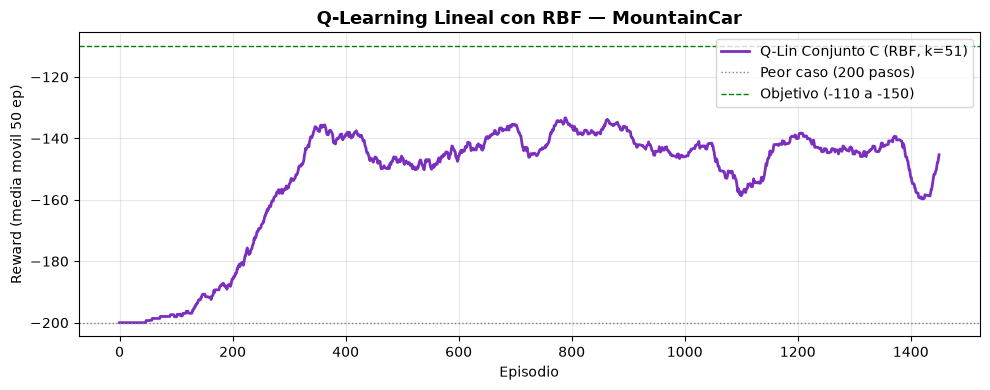

Reward greedy final (media 10 ep): -141.1
Pasos por episodio en test: [-139.0, -142.0, -143.0, -139.0, -139.0, -144.0, -142.0, -141.0, -141.0, -141.0]


In [4]:
# Entrenar con features RBF (Conjunto C, k=51) para alcanzar el objetivo
np.random.seed(42)
print("Entrenando Q-Learning lineal con Conjunto C (RBF, k=51)...")
theta_RBF, rewards_RBF = q_linear(
    env, features_RBF, k=51, n_episodes=1500, alpha=0.03, epsilon_decay=0.995
)


# Media movil
def moving_avg(data, window=50):
    return np.convolve(data, np.ones(window) / window, mode="valid")


fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    moving_avg(rewards_RBF, 50),
    color="#7B2FBE",
    linewidth=2,
    label="Q-Lin Conjunto C (RBF, k=51)",
)
ax.axhline(
    -200, color="gray", linestyle=":", linewidth=1, label="Peor caso (200 pasos)"
)
ax.axhline(
    -110, color="green", linestyle="--", linewidth=1, label="Objetivo (-110 a -150)"
)
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward (media movil 50 ep)")
ax.set_title("Q-Learning Lineal con RBF — MountainCar", fontweight="bold", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluar: correr 10 episodios greedy al final
test_rewards = []
for _ in range(10):
    obs, _ = env.reset()
    total_r = 0
    while True:
        Qs = [np.dot(theta_RBF, features_RBF(obs, a)) for a in range(3)]
        obs, r, done, trunc, _ = env.step(np.argmax(Qs))
        total_r += r
        if done or trunc:
            break
    test_rewards.append(total_r)
print(f"Reward greedy final (media 10 ep): {np.mean(test_rewards):.1f}")
print("Pasos por episodio en test:", test_rewards)

T3 Comparacion


Entrenando Conjunto A (k=9)...


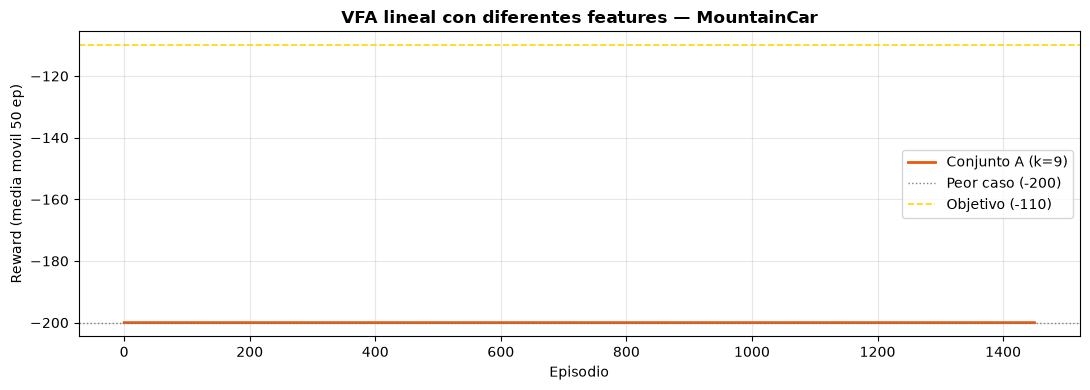

In [ ]:
# Entrenar los 3 conjuntos con particionamiento por accion
configs = [
    # ("Conjunto A (k=9)", features_A, 9, 0.1, "#EA580C"),
    # ("Conjunto B (k=27)", features_B, 27, 0.005, "#00AEEF"),
    ("RBF (k=51)", features_RBF, 51, 0.03, "#7B2FBE"),
]

all_rewards = {}
for name, feat_fn, k, alpha, color in configs:
    print(f"Entrenando {name}...")
    _, rewards = q_linear(
        env, feat_fn, k=k, n_episodes=1500, alpha=alpha, epsilon_decay=0.995
    )
    all_rewards[name] = rewards

# Graficar comparacion
fig, ax = plt.subplots(figsize=(11, 4))
for name, _, _, _, color in configs:
    rewards = all_rewards[name]
    ax.plot(moving_avg(rewards, 50), color=color, linewidth=2, label=name)
ax.axhline(-200, color="gray", linestyle=":", linewidth=1, label="Peor caso (-200)")
ax.axhline(-110, color="gold", linestyle="--", linewidth=1.2, label="Objetivo (-110)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward (media movil 50 ep)")
ax.set_title("VFA lineal con diferentes features — MountainCar", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Entrenando RBF (k=51)...


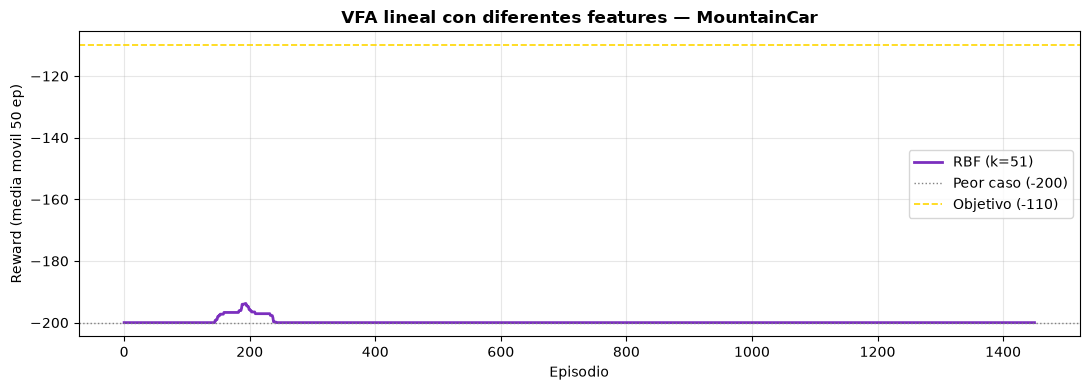

In [52]:
configs = [
    # ("Conjunto A (k=9)", features_A, 9, 0.1, "#EA580C"),
    # ("Conjunto B (k=27)", features_B, 27, 0.005, "#00AEEF"),
    ("RBF (k=51)", features_RBF, 51, 0.03, "#7B2FBE"),
]

all_rewards = {}
for name, feat_fn, k, alpha, color in configs:
    print(f"Entrenando {name}...")
    _, rewards = q_linear(
        env, feat_fn, k=k, n_episodes=1500, alpha=alpha, epsilon_decay=0.995
    )
    all_rewards[name] = rewards

# Graficar comparacion
fig, ax = plt.subplots(figsize=(11, 4))
for name, _, _, _, color in configs:
    rewards = all_rewards[name]
    ax.plot(moving_avg(rewards, 50), color=color, linewidth=2, label=name)
ax.axhline(-200, color="gray", linestyle=":", linewidth=1, label="Peor caso (-200)")
ax.axhline(-110, color="gold", linestyle="--", linewidth=1.2, label="Objetivo (-110)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward (media movil 50 ep)")
ax.set_title("VFA lineal con diferentes features — MountainCar", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Prueba alpha=0.1 con Conjunto A. ¿Diverge o converge? ¿Por que alpha alto es peligroso con features simples?**

> Diverge. Alpha alto es peligroso con features simples porque puede causar que los pesos se actualicen demasiado rápido, lo que lleva a oscilaciones y falta de convergencia en el aprendizaje.

**Aumenta sigma de RBF de 0.6 a 1.5. ¿Los kernelsse vuelven mas o menos locales? ¿Como afecta la convergencia?**

>

**Para MountainCar, la interaccion posicion·velocidad(x·v) es importante. ¿Que le pasaría a Conjunto B si quitamos ese termino?**

>


Parte 2: Laboratorio Propuesto

C1: RBF Grid Search


In [6]:
#  Grid search sobre n_centros y sigma (con particionamiento por accion)
n_centers_list = [3, 5]
sigma_list = [0.4, 0.6]
results_grid = {}

for nc in n_centers_list:
    for sig in sigma_list:
        centers_x2 = np.linspace(-1, 1, nc)
        centers_v2 = np.linspace(-1, 1, nc)
        dim_psi = nc**2 + 1
        k_rbf = dim_psi * nA  # RBF + bias, particionado por accion

        def feat_rbf_custom(
            obs, action, nc=nc, sig=sig, cx=centers_x2, cv=centers_v2, d_psi=dim_psi
        ):
            s = normalize_state(obs)
            psi = []
            for ccx in cx:
                for ccv in cv:
                    d2 = (s[0] - ccx) ** 2 + (s[1] - ccv) ** 2
                    psi.append(np.exp(-d2 / (2 * sig**2)))
            psi.append(1.0)
            psi = np.array(psi)
            phi = np.zeros(d_psi * nA)
            phi[action * d_psi : (action + 1) * d_psi] = psi
            return phi

        _, rewards = q_linear(
            env,
            feat_rbf_custom,
            k=k_rbf,
            n_episodes=1200,
            alpha=0.03,
            epsilon_decay=0.995,
        )
        final_r = np.mean(rewards[-100:])
        results_grid[(nc, sig)] = final_r
        print(f"  nc={nc}, sigma={sig:.1f}: reward_final={final_r:.1f}")

best = max(results_grid, key=results_grid.get)
print(
    f"Mejor combinacion: nc={best[0]}, sigma={best[1]}, reward={results_grid[best]:.1f}"
)

  nc=3, sigma=0.4: reward_final=-200.0
  nc=3, sigma=0.6: reward_final=-140.1
  nc=5, sigma=0.4: reward_final=-147.7
  nc=5, sigma=0.6: reward_final=-151.2
Mejor combinacion: nc=3, sigma=0.6, reward=-140.1


C2 Fourier features


In [7]:
# Bases de Fourier para estado continuo con particionamiento por accion
def features_fourier(obs, action, n_freq=3):
    s = normalize_state(obs)
    psi = [1.0]  # bias
    for f in range(1, n_freq + 1):
        psi.append(np.sin(f * np.pi * s[0]))
        psi.append(np.cos(f * np.pi * s[0]))
        psi.append(np.sin(f * np.pi * s[1]))
        psi.append(np.cos(f * np.pi * s[1]))
    psi = np.array(psi)
    phi = np.zeros(len(psi) * nA)
    phi[action * len(psi) : (action + 1) * len(psi)] = psi
    return phi


dim_psi_fourier = 1 + 4 * 3  # bias + 3freq*4componentes = 13
k_fourier = dim_psi_fourier * nA  # 13 x 3 = 39
print(f"k_fourier = {k_fourier}")

_, rewards_fourier = q_linear(
    env,
    lambda o, a: features_fourier(o, a, n_freq=3),
    k=k_fourier,
    n_episodes=1500,
    alpha=0.01,
    epsilon_decay=0.995,
)
print(f"Fourier reward final (ultimos 100 ep): {np.mean(rewards_fourier[-100:]):.1f}")

k_fourier = 39
Fourier reward final (ultimos 100 ep): -128.3


c3 Sarsa con VFA


In [8]:
def sarsa_linear(
    env,
    feature_fn,
    k,
    n_episodes=2000,
    alpha=0.03,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
):
    """SARSA con VFA lineal y particionamiento por accion."""
    theta = np.zeros(k)
    rewards = []
    epsilon = epsilon_start

    for ep in range(n_episodes):
        obs, _ = env.reset()
        Qs = [np.dot(theta, feature_fn(obs, a)) for a in range(env.action_space.n)]
        action = (
            env.action_space.sample()
            if np.random.rand() < epsilon
            else int(np.argmax(Qs))
        )
        total_r = 0

        while True:
            obs_next, r, done, trunc, _ = env.step(action)
            total_r += r

            # SARSA: elegir a' con ε-greedy (on-policy)
            Qs_next = [
                np.dot(theta, feature_fn(obs_next, a))
                for a in range(env.action_space.n)
            ]
            action_next = (
                env.action_space.sample()
                if np.random.rand() < epsilon
                else int(np.argmax(Qs_next))
            )

            # Target SARSA: solo anular si llega a la meta real ('done')
            phi = feature_fn(obs, action)
            target = r + (
                0.0
                if done
                else gamma * np.dot(theta, feature_fn(obs_next, action_next))
            )
            theta += alpha * (target - np.dot(theta, phi)) * phi

            obs, action = obs_next, action_next
            if done or trunc:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards.append(total_r)

    return theta, rewards


print("Entrenando SARSA con RBF (k=51)...")
theta_sarsa, rewards_sarsa = sarsa_linear(
    env, features_RBF, k=51, n_episodes=1500, alpha=0.03
)
print(f"SARSA RBF reward final: {np.mean(rewards_sarsa[-100:]):.1f}")

Entrenando SARSA con RBF (k=51)...
SARSA RBF reward final: -199.7


**En tu gridsearch, ¿que ocurre con sigma muy pequeño (0.1)? ¿Y con sigma muy grande (2.0)? Explica el comportamiento en terminos de localización vs generalización de las features.**

>

**SARSA vs Q-Learningcon VFA lineal: ¿cual es mas estable en tus experimentos? ¿Es consistente con la teoría (triada mortal)? Justifica con las curvas de reward.**

>

**Si aumentas el numero de features de 6 a 100 (overfittingcon VFA), ¿que esperas que pase? ¿Converge mas rápido o diverge? ¿Cuando VFA lineal no es suficiente y necesitas una red neuronal?**

>
